In [1]:
import requests
#The requests library is used for making HTTP requests, which is essential for fetching data from web APIs or scraping websites
import pandas as pd
import time
#The time library is often used to pause execution (time.sleep()) to avoid overwhelming servers when making multiple API requests, or for measuring the execution time of code blocks.

In [25]:
def build_pokemon_dataset(limit=151):
  pokemon_list=[]
  print("Kanto ppokemon data loading in Pokedex")
  for i in range(1, limit+1):
    url = f"https://pokeapi.co/api/v2/pokemon/{i}"
    response = requests.get(url)

    if response.status_code == 200:
      data = response.json()
      # Unpacking the stats from the API's nested structure
      stats = {s['stat']['name']: s['base_stat'] for s in data['stats']}
      # Formatting our clean dataset row
      pokemon_row = {
                "id": data['id'],
                "name": data['name'],
                "hp": stats.get('hp'),
                "attack": stats.get('attack'),
                "defense": stats.get('defense'),
                "speed": stats.get('speed'),
                "type": data['types'][0]['type']['name']
      }
      pokemon_list.append(pokemon_row)
    #   if i % 30 == 0:
    #      print(f"Fetched {i}/{limit} Pokémon...")
    # else:
    #   print(f"Failed to fetch ID {i}")

    # time.sleep(0.02) # A tiny pause to be respectful to the free server

  print("and done..finally 😭")
  return pd.DataFrame(pokemon_list)

In [26]:
# Execute the function and save it into a variable named 'df'
df = build_pokemon_dataset(151)

Kanto ppokemon data loading in Pokedex
and done..finally 😭


In [4]:
df.head()

,id,name,hp,attack,defense,speed,type
0,1,bulbasaur,45,49,49,45,grass
1,2,ivysaur,60,62,63,60,grass
2,3,venusaur,80,82,83,80,grass
3,4,charmander,39,52,43,65,fire
4,5,charmeleon,58,64,58,80,fire


In [27]:
from sklearn.preprocessing import LabelEncoder

# 1. Separate our independent variables (Features) from our target (Label)
# We want the AI to look at stats, so we drop 'id', 'name', and the answer key 'type'
X = df.drop(columns=['id', 'name', 'type'])

# 2. Extract our target answer key
y_raw = df['type']

# 3. Create our LabelEncoder object and transform text to numbers
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)

# categorial data to numeric values
# grass = 0 , fire = 2 , water =3 and blahblah

# --- QUICK VERIFICATION PRINTS ---
print("FEATURES (X) ")
print(X.head()) # Should show just the numeric stat columns

print("\nCODED LABELS (y)")
print(y[:10]) # Should show an array of numbers like [6, 6, 6, 9, 9...]

print("\nTYPE MAPPER KEY")
# This shows us exactly which number corresponds to which element type
for index, element in enumerate(encoder.classes_):
    print(f"Number {index} = {element}")

FEATURES (X) 
   hp  attack  defense  speed
0  45      49       49     45
1  60      62       63     60
2  80      82       83     80
3  39      52       43     65
4  58      64       58     80

CODED LABELS (y)
[ 7  7  7  5  5  5 14 14 14  0]

TYPE MAPPER KEY
Number 0 = bug
Number 1 = dragon
Number 2 = electric
Number 3 = fairy
Number 4 = fighting
Number 5 = fire
Number 6 = ghost
Number 7 = grass
Number 8 = ground
Number 9 = ice
Number 10 = normal
Number 11 = poison
Number 12 = psychic
Number 13 = rock
Number 14 = water


In [28]:
from sklearn.ensemble import RandomForestClassifier

# 1. Create the AI Model Object
# n_estimators=100 means we want 100 decision trees in our forest.
# random_state=42 is just a seed number to make sure the randomness
# behaves exactly the same way every time we run the cell.
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model!
# In Scikit-Learn, '.fit()' means "study this data and learn the patterns".
# We pass it the features (X) and the corresponding correct answers (y).
model.fit(X, y)

print("🎉 Model Training Complete!successfully studied the 151 Kanto buddys.")

# 3. Calculate how well it memorized the training patterns
accuracy = model.score(X, y) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

🎉 Model Training Complete!successfully studied the 151 Kanto buddys.
Training Accuracy: 100.00%


**The Intelligent Matchmaker**

In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Generate the "Stat Identity Vectors" for all 151 Pokémon
# This extracts the underlying type probabilities the model calculates for each row
all_profiles = model.predict_proba(X)

def recommend_perfect_teammate(pokemon_name):
    """
    Takes a Pokémon name, analyzes its AI combat profile,
    and recommends the most strategically complementary teammate.
    """
    # Clean the input name string to lowercase
    pokemon_name = pokemon_name.lower().strip()

    # Quick error check: Make sure the name exists in our dataframe
    if pokemon_name not in df['name'].values:
        return f"Error: '{pokemon_name}' not found in the Gen 1 database."

    # Find the row index of our chosen Pokémon
    idx = df[df['name'] == pokemon_name].index[0]

    # Get the AI profile vector for our chosen Pokémon
    chosen_profile = all_profiles[idx].reshape(1, -1)

    # Compute the similarity score between our chosen Pokémon and ALL 151 rows
    similarity_scores = cosine_similarity(chosen_profile, all_profiles)[0]

    # STRATEGY LOGIC: We want a complementary teammate, NOT a carbon copy.
    # Therefore, we want to look for low similarity scores (different stat/type footprints),
    # but we want them to be highly rated overall.
    # Let's find the lowest similarity score in the entire index!
    best_match_idx = np.argmin(similarity_scores)

    # Extract the winning teammate's details
    teammate_name = df.iloc[best_match_idx]['name']
    teammate_type = df.iloc[best_match_idx]['type']

    print(f"🔮 [AI Analysis]: Your '{pokemon_name.capitalize()}' is a great choice.")
    print(f"🤝 [Recommendation]: To balance your team, you should pair it with: {teammate_name.capitalize()} ({teammate_type.capitalize()}-type)!")
    print(f"📊 [Matchmaker Score]: Strategy Differentiation Index = {(1 - similarity_scores[best_match_idx]):.2f}")

# --- TEST THE RECOMMENDATION SYSTEM ---
recommend_perfect_teammate("jolteon")

🔮 [AI Analysis]: Your 'Jolteon' is a great choice.
🤝 [Recommendation]: To balance your team, you should pair it with: Flareon (Fire-type)!
📊 [Matchmaker Score]: Strategy Differentiation Index = 1.00


# **POKEMON GO matchmaking**

In [ ]:
def build_go_3v3_team(starter_name):
    """
    Takes a starter Pokémon and uses the AI model's profile matrix
    to select 2 optimal teammates to complete a 3v3 Pokémon GO team.
    """
    starter_name = starter_name.lower().strip()

    if starter_name not in df['name'].values:
        return f"Error: '{starter_name}' not found."

    # 1. Identify the Starter
    starter_idx = df[df['name'] == starter_name].index[0]
    starter_profile = all_profiles[starter_idx].reshape(1, -1)

    # 2. Calculate similarities across the whole Pokedex
    scores = cosine_similarity(starter_profile, all_profiles)[0]

    # To prevent recommending the starter to itself, set its score very high
    scores[starter_idx] = 999

    # 3. Find the "Safe Switch" (The polar opposite stat profile for coverage)
    # We find the absolute lowest similarity score to the starter
    safe_switch_idx = np.argmin(scores)
    safe_switch_profile = all_profiles[safe_switch_idx].reshape(1, -1)

    # Ensure we don't pick this one again next step
    scores[safe_switch_idx] = 999

    # 4. Find the "Closer" (Balances out the team)
    # We want a Pokémon that bridges the gap between your lead and your tank
    combined_team_profile = (starter_profile + safe_switch_profile) / 2
    team_scores = cosine_similarity(combined_team_profile, all_profiles)[0]

    # Set already used items to 0 so they aren't re-picked
    team_scores[starter_idx] = 0
    team_scores[safe_switch_idx] = 0

    # The closer should complement the combined team's average footprint
    closer_idx = np.argmax(team_scores)

    # Gather results
    p1 = df.iloc[starter_idx]
    p2 = df.iloc[safe_switch_idx]
    p3 = df.iloc[closer_idx]

    print(f"⚔️ --- AI POKÉMON GO 3v3 TEAM COMPOSITION --- ⚔️\n")
    print(f"🥊 POSITION 1: LEAD")
    print(f"   👉 {p1['name'].capitalize()} ({p1['type'].capitalize()} | HP: {p1['hp']}, ATK: {p1['attack']})")
    print(f"   *Your frontline shield-pressure generator.*\n")

    print(f"🛡️ POSITION 2: SAFE SWITCH")
    print(f"   👉 {p2['name'].capitalize()} ({p2['type'].capitalize()} | HP: {p2['hp']}, DEF: {p2['defense']})")
    print(f"   *Swap to this if your Lead hits a bad matchup. This covers your Lead's statistical flaws.*\n")

    print(f"💥 POSITION 3: CLOSER")
    print(f"   👉 {p3['name'].capitalize()} ({p3['type'].capitalize()} | ATK: {p3['attack']}, SPD: {p3['speed']})")
    print(f"   *Your final cleanup hitter to sweep when shields are gone.*")

# --- TEST YOUR POKÉMON GO TEAM ---
build_go_3v3_team("machamp")

⚔️ --- AI POKÉMON GO 3v3 TEAM COMPOSITION --- ⚔️

🥊 POSITION 1: LEAD
   👉 Machamp (Fighting | HP: 90, ATK: 130)
   *Your frontline shield-pressure generator.*

🛡️ POSITION 2: SAFE SWITCH
   👉 Voltorb (Electric | HP: 40, DEF: 50)
   *Swap to this if your Lead hits a bad matchup. This covers your Lead's statistical flaws.*

💥 POSITION 3: CLOSER
   👉 Hitmonchan (Fighting | ATK: 105, SPD: 76)
   *Your final cleanup hitter to sweep when shields are gone.*


TESTT

In [ ]:
build_go_3v3_team("dragonite")

⚔️ --- AI POKÉMON GO 3v3 TEAM COMPOSITION --- ⚔️

🥊 POSITION 1: LEAD
   👉 Dragonite (Dragon | HP: 91, ATK: 134)
   *Your frontline shield-pressure generator.*

🛡️ POSITION 2: SAFE SWITCH
   👉 Raichu (Electric | HP: 60, DEF: 55)
   *Swap to this if your Lead hits a bad matchup. This covers your Lead's statistical flaws.*

💥 POSITION 3: CLOSER
   👉 Pikachu (Electric | ATK: 55, SPD: 90)
   *Your final cleanup hitter to sweep when shields are gone.*


# **SMARTER**

In [ ]:
def build_smart_go_team(starter_name):
    starter_name = starter_name.lower().strip()
    if starter_name not in df['name'].values:
        return f"Error: '{starter_name}' not found."

    # Hardcoded lookups for Type Vulnerabilities to teach our AI basic battle logic
    counters_needed = {
        "electric": ["grass", "water", "ice"], # Electric loses to Ground, so we need Water/Grass to beat Ground
        "fire": ["water", "rock", "ground"],
        "water": ["electric", "grass"],
        "grass": ["fire", "flying", "ice"],
        "poison": ["ground", "psychic"],
        "flying": ["electric", "rock", "ice"],
        "fighting": ["psychic", "flying", "fairy"]
    }

    # Identify starter data
    starter_idx = df[df['name'] == starter_name].index[0]
    starter_type = df.iloc[starter_idx]['type']

    # 1. Use our ML Model profile vector just like before
    starter_profile = all_profiles[starter_idx].reshape(1, -1)
    scores = cosine_similarity(starter_profile, all_profiles)[0]

    # 2. APPLY TYPE CORRECTION LAYER (The AI logic upgrade)
    # If the starter is Electric, we want to actively boost types that cover its weaknesses
    desired_types = counters_needed.get(starter_type, ["normal"])

    adjusted_scores = scores.copy()
    for idx, row in df.iterrows():
        # Penalize identical types so we don't get 3 of the same element
        if row['type'] == starter_type:
            adjusted_scores[idx] += 0.5 # Push similarity UP so argmin avoids it

        # Reward types that counter our starter's natural enemies
        if row['type'] in desired_types:
            adjusted_scores[idx] -= 0.6 # Pull similarity DOWN to make it highly attractive

    # Remove starter from picking itself
    adjusted_scores[starter_idx] = 999

    # Select Safe Switch and Closer based on the upgraded type-logic scores
    safe_switch_idx = np.argmin(adjusted_scores)
    adjusted_scores[safe_switch_idx] = 999

    closer_idx = np.argmin(adjusted_scores)

    # Output results
    p1 = df.iloc[starter_idx]
    p2 = df.iloc[safe_switch_idx]
    p3 = df.iloc[closer_idx]

    print(f"⚔️ --- UPGRADED TYPE-SAFE 3v3 TEAM FOR POKÉMON GO --- ⚔️\n")
    print(f"🥊 LEAD:        {p1['name'].capitalize()} ({p1['type'].capitalize()})")
    print(f"🛡️ SAFE SWITCH: {p2['name'].capitalize()} ({p2['type'].capitalize()}) <- Covers your weaknesses!")
    print(f"💥 CLOSER:      {p3['name'].capitalize()} ({p3['type'].capitalize()})")



⚔️ --- UPGRADED TYPE-SAFE 3v3 TEAM FOR POKÉMON GO --- ⚔️

🥊 LEAD:        Jolteon (Electric)
🛡️ SAFE SWITCH: Bellsprout (Grass) <- Covers your weaknesses!
💥 CLOSER:      Exeggutor (Grass)


# **The smart tester**

In [ ]:
build_smart_go_team("jolteon")

⚔️ --- UPGRADED TYPE-SAFE 3v3 TEAM FOR POKÉMON GO --- ⚔️

🥊 LEAD:        Jolteon (Electric)
🛡️ SAFE SWITCH: Bellsprout (Grass) <- Covers your weaknesses!
💥 CLOSER:      Exeggutor (Grass)


# **THE ultimate go triangle**

In [8]:
def build_ultimate_go_triangle(starter_name):
    starter_name = starter_name.lower().strip()
    if starter_name not in df['name'].values:
        return f"Error: '{starter_name}' not found."

    # Weaknesss
    type_weaknesses = {
        "electric": ["ground"],
        "fire": ["water", "rock", "ground"],
        "water": ["electric", "grass"],
        "grass": ["fire", "flying", "poison", "bug", "ice"],
        "poison": ["ground", "psychic"],
        "flying": ["electric", "rock", "ice"],
        "fighting": ["psychic", "flying", "fairy"],
        "normal": ["fighting"],
        "rock": ["water", "grass", "fighting", "ground", "steel"],
        "ground": ["water", "grass", "ice"],
        "bug": ["fire", "flying", "rock"],
        "ghost": ["ghost", "dark"],
        "psychic": ["bug", "ghost", "dark"],
        "ice": ["fire", "fighting", "rock", "steel"],
        "dragon": ["ice", "dragon", "fairy"]
    }

    # 1. Get our starter data
    p1_row = df[df['name'] == starter_name].iloc[0]
    p1_type = p1_row['type']
    p1_weaknesses = type_weaknesses.get(p1_type, [])

    best_team = None
    highest_synergy_score = -999

    # 2. BRUTE FORCE SEARCH (The AI checks all possible pairs of teammates)
    # We loop through every single Pokémon to find Candidate #2
    for idx2, p2_row in df.iterrows():
        if p2_row['name'] == starter_name: continue
        p2_type = p2_row['type']
        p2_weaknesses = type_weaknesses.get(p2_type, [])

        # RULE 1: Safe Switch cannot share a weakness with the Starter!
        if any(weakness in p1_weaknesses for weakness in p2_weaknesses):
            continue # Skip this synergy, it's too risky

        # We loop through every single Pokémon again to find Candidate #3
        for idx3, p3_row in df.iterrows():
            if p3_row['name'] == starter_name or p3_row['name'] == p2_row['name']: continue
            p3_type = p3_row['type']
            p3_weaknesses = type_weaknesses.get(p3_type, [])

            # RULE 2: Closer cannot share a weakness with the Starter OR the Safe Switch!
            if any(weakness in p1_weaknesses for weakness in p3_weaknesses): continue
            if any(weakness in p2_weaknesses for weakness in p3_weaknesses): continue

            # 3. CALCULATE SYNERGY SCORE USING MACHINE LEARNING PROBABILITIES
            # We want them to have diverse physical stats (calculated by our ML vectors)
            p1_prof = all_profiles[p1_row['id'] - 1]
            p2_prof = all_profiles[p2_row['id'] - 1]
            p3_prof = all_profiles[p3_row['id'] - 1]

            # Measure how statistically diverse their body shapes/stats are
            # Lower cosine similarity means they fill completely different combat roles (Tank vs Fast)
            stat_diversity = 2 - (cosine_similarity([p1_prof], [p2_prof])[0][0] +
                                  cosine_similarity([p2_prof], [p3_prof])[0][0])

            # If this combination has the highest diversity score, save it as the winner!
            if stat_diversity > highest_synergy_score:
                highest_synergy_score = stat_diversity
                best_team = (p1_row, p2_row, p3_row)

    # Print the flawless team result
    if best_team:
        p1, p2, p3 = best_team
        print(f"🛡️ --- THE ULTIMATE SYNERGY TRIANGLE FOR POKÉMON GO --- 🛡️\n")
        print(f"🥊 LEAD:        {p1['name'].capitalize()} ({p1['type'].capitalize()})")
        print(f"🛡️ SAFE SWITCH: {p2['name'].capitalize()} ({p2['type'].capitalize()})")
        print(f"💥 CLOSER:      {p3['name'].capitalize()} ({p3['type'].capitalize()})")
        print(f"\n🔒 Zero Shared Weaknesses Detected! This team forms a complete protective loop.")
    else:
        print("Could not find a perfect 0-weakness loop with this starter. Try another!")

# Run the master builder!

In [9]:
build_ultimate_go_triangle("dragonite")

🛡️ --- THE ULTIMATE SYNERGY TRIANGLE FOR POKÉMON GO --- 🛡️

🥊 LEAD:        Dragonite (Dragon)
🛡️ SAFE SWITCH: Raichu (Electric)
💥 CLOSER:      Hypno (Psychic)

🔒 Zero Shared Weaknesses Detected! This team forms a complete protective loop.


In [10]:
# Save our cleaned DataFrame as a CSV file in your Colab workspace
df.to_csv('pokemon_dataset.csv', index=False)
print("Spreadsheet successfully saved!")

Spreadsheet successfully saved!


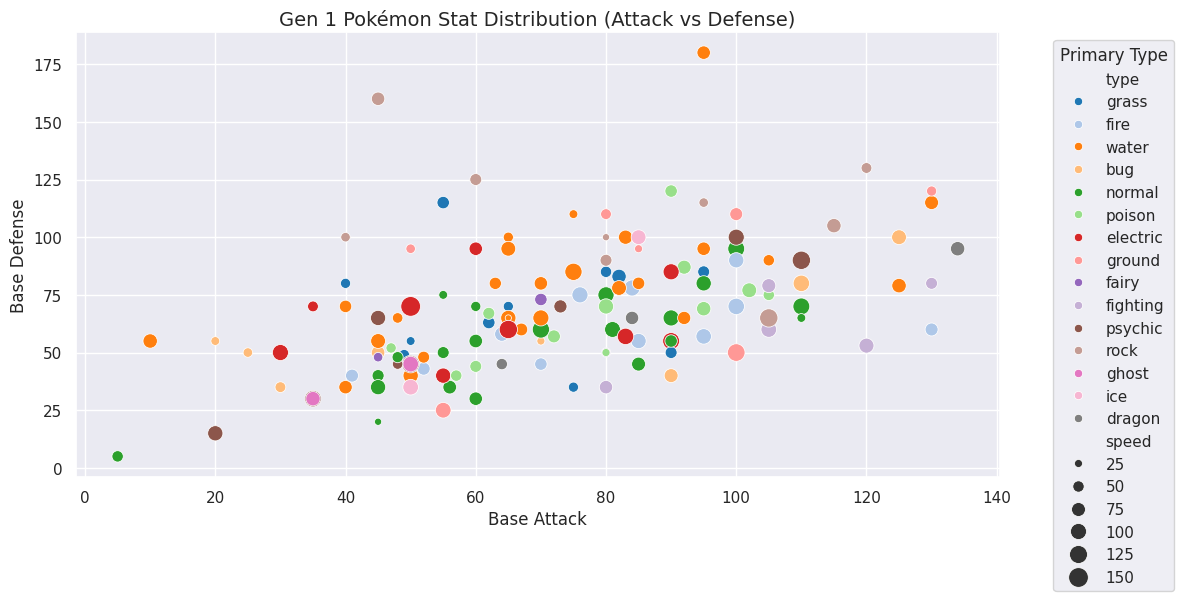

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the styling for our charts
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# Create a scatter plot comparing Attack vs Defense, colored by Type
sns.scatterplot(
    data=df,
    x='attack',
    y='defense',
    hue='type',
    size='speed',
    sizes=(20, 200),
    palette='tab20'
)

plt.title("Gen 1 Pokémon Stat Distribution (Attack vs Defense)", fontsize=14)
plt.xlabel("Base Attack", fontsize=12)
plt.ylabel("Base Defense", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Primary Type')
plt.tight_layout()

# Show the chart directly in Colab
plt.show()

In [12]:
# Extract how much weight the AI gave to each stat column
importances = model.feature_importances_
feature_names = X.columns

# Print the breakdown
print("🧠 --- AI FEATURE IMPORTANCE WEIGHTS ---")
for name, importance in zip(feature_names, importances):
    print(f"👉 {name.upper()}: {importance * 100:.2f}% of the decision power")

🧠 --- AI FEATURE IMPORTANCE WEIGHTS ---
👉 HP: 23.32% of the decision power
👉 ATTACK: 23.92% of the decision power
👉 DEFENSE: 25.53% of the decision power
👉 SPEED: 27.23% of the decision power


In [18]:
import time
from IPython.display import Audio, display, clear_output

def build_ultimate_go_team_with_triple_sound(starter_name):
    starter_name = starter_name.lower().strip()
    if starter_name not in df['name'].values:
        return f"Error: '{starter_name}' not found."

    type_weaknesses = {
        "electric": ["ground"], "fire": ["water", "rock", "ground"],
        "water": ["electric", "grass"], "grass": ["fire", "flying", "poison", "bug", "ice"],
        "poison": ["ground", "psychic"], "flying": ["electric", "rock", "ice"],
        "fighting": ["psychic", "flying", "fairy"], "normal": ["fighting"],
        "rock": ["water", "grass", "fighting", "ground", "steel"], "ground": ["water", "grass", "ice"],
        "bug": ["fire", "flying", "rock"], "ghost": ["ghost", "dark"],
        "psychic": ["bug", "ghost", "dark"], "ice": ["fire", "fighting", "rock", "steel"],
        "dragon": ["ice", "dragon", "fairy"]
    }

    p1_row = df[df['name'] == starter_name].iloc[0]
    p1_weaknesses = type_weaknesses.get(p1_row['type'], [])
    best_team, highest_synergy = None, -999

    for idx2, p2_row in df.iterrows():
        if p2_row['name'] == starter_name: continue
        p2_weaknesses = type_weaknesses.get(p2_row['type'], [])
        if any(w in p1_weaknesses for w in p2_weaknesses): continue

        for idx3, p3_row in df.iterrows():
            if p3_row['name'] in [starter_name, p2_row['name']]: continue
            p3_weaknesses = type_weaknesses.get(p3_row['type'], [])
            if any(w in p1_weaknesses for w in p3_weaknesses) or any(w in p2_weaknesses for w in p3_weaknesses): continue

            p1_prof, p2_prof, p3_prof = all_profiles[p1_row['id']-1], all_profiles[p2_row['id']-1], all_profiles[p3_row['id']-1]
            stat_diversity = 2 - (cosine_similarity([p1_prof], [p2_prof])[0][0] + cosine_similarity([p2_prof], [p3_prof])[0][0])

            if stat_diversity > highest_synergy:
                highest_synergy = stat_diversity
                best_team = (p1_row, p2_row, p3_row)

    if best_team:
        p1, p2, p3 = best_team

        print(f"⚔️ --- THE ULTIMATE SYNERGY TRIANGLE --- ⚔️\n")
        print(f"🥊 POSITION 1 [LEAD]:        {p1['name'].capitalize()} ({p1['type'].capitalize()})")
        print(f"🛡️ POSITION 2 [SAFE SWITCH]: {p2['name'].capitalize()} ({p2['type'].capitalize()})")
        print(f"💥 POSITION 3 [CLOSER]:      {p3['name'].capitalize()} ({p3['type'].capitalize()})\n")
        print("-" * 43)
        print("🔊 Initiating Team Battle Cry Sequence...")
        print("-" * 43)

        # Array of our chosen team members to loop through
        team_lineup = [
            {"role": "LEAD", "name": p1['name'], "id": p1['id']},
            {"role": "SAFE SWITCH", "name": p2['name'], "id": p2['id']},
            {"role": "CLOSER", "name": p3['name'], "id": p3['id']}
        ]

        # Loop over each teammate, print their entry message, and blast their sound effect
        for member in team_lineup:
            print(f"✨ Summoning {member['role']} -> {member['name'].upper()}! ✨")

            # Use the official PokeAPI raw cloud file structure for ogg game audio files
            audio_url = f"https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/latest/{member['id']}.ogg"

            # Deploy and trigger the audio element to play through the browser session
            display(Audio(url=audio_url, autoplay=True))

            # Pause for 1.5 seconds to let the audio finish completely before the next team member drops in
            time.sleep(1.5)

        print("\n🏆 Squad fully compiled and locked down! Good luck on the battle ladder!")
    else:
        print("No flawless triangle combination found for this starter.")

# Test out the full squad's audio deck!
build_ultimate_go_team_with_triple_sound("dragonite")

⚔️ --- THE ULTIMATE SYNERGY TRIANGLE --- ⚔️

🥊 POSITION 1 [LEAD]:        Dragonite (Dragon)
🛡️ POSITION 2 [SAFE SWITCH]: Raichu (Electric)
💥 POSITION 3 [CLOSER]:      Hypno (Psychic)

-------------------------------------------
🔊 Initiating Team Battle Cry Sequence...
-------------------------------------------
✨ Summoning LEAD -> DRAGONITE! ✨


✨ Summoning SAFE SWITCH -> RAICHU! ✨


✨ Summoning CLOSER -> HYPNO! ✨



🏆 Squad fully compiled and locked down! Good luck on the battle ladder!
